<a href="https://colab.research.google.com/github/kalvii631/Machine-learning/blob/main/ML_Exp_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. IMPORT LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
# 2. LOAD DATASET
ratings = pd.read_csv('ratings.csv')
movies = pd.read_csv('movies.csv')

if 'timestamp' in ratings.columns:
    ratings = ratings.drop('timestamp', axis=1)

In [3]:
# 3. USER-ITEM MATRIX
user_item_matrix = ratings.pivot(index='userId', columns='movieId', values='rating')

In [4]:
# 4. NORMALIZATION (IMPORTANT FIX)
# Use mean only on available ratings (NOT filled zeros)
user_mean = user_item_matrix.mean(axis=1)
# Subtract mean and fill missing with 0 AFTER normalization
matrix_norm = user_item_matrix.sub(user_mean, axis=0).fillna(0)

In [5]:
# 5. APPLY SVD
U, sigma, Vt = np.linalg.svd(matrix_norm, full_matrices=False)

k = 15   # Reduced k for better generalization
U_k = U[:, :k]
sigma_k = np.diag(sigma[:k])
Vt_k = Vt[:k, :]

In [6]:
# 6. RECONSTRUCTION
reconstructed = np.dot(np.dot(U_k, sigma_k), Vt_k)

# Add mean back
reconstructed += user_mean.values.reshape(-1, 1)

pred_svd = pd.DataFrame(reconstructed,
                        index=user_item_matrix.index,
                        columns=user_item_matrix.columns)

In [7]:
# 7. EVALUATION (CORRECT)
mask = user_item_matrix.notna()

actual = user_item_matrix.values[mask]
predicted = pred_svd.values[mask]

rmse = np.sqrt(mean_squared_error(actual, predicted))
mae = mean_absolute_error(actual, predicted)
print("24BAD033 HARSHAVARTHAN SB")
print("SVD RMSE:", rmse)
print("SVD MAE:", mae)

24BAD033 HARSHAVARTHAN SB
SVD RMSE: 0.7729268967084666
SVD MAE: 0.5578974831914701


In [8]:
# 8. RECOMMENDATIONS
def recommend_svd(user_id, n=5):
    user_row = pred_svd.loc[user_id]
    already_rated = user_item_matrix.loc[user_id].dropna().index
    recs = user_row.drop(already_rated).sort_values(ascending=False).head(n)
    return movies[movies['movieId'].isin(recs.index)][['movieId', 'title']]

print("\nTop Recommendations for User 1:")
print(recommend_svd(1))


Top Recommendations for User 1:
      movieId                                              title
31         32          Twelve Monkeys (a.k.a. 12 Monkeys) (1995)
277       318                   Shawshank Redemption, The (1994)
474       541                                Blade Runner (1982)
659       858                              Godfather, The (1972)
4800     7153  Lord of the Rings: The Return of the King, The...


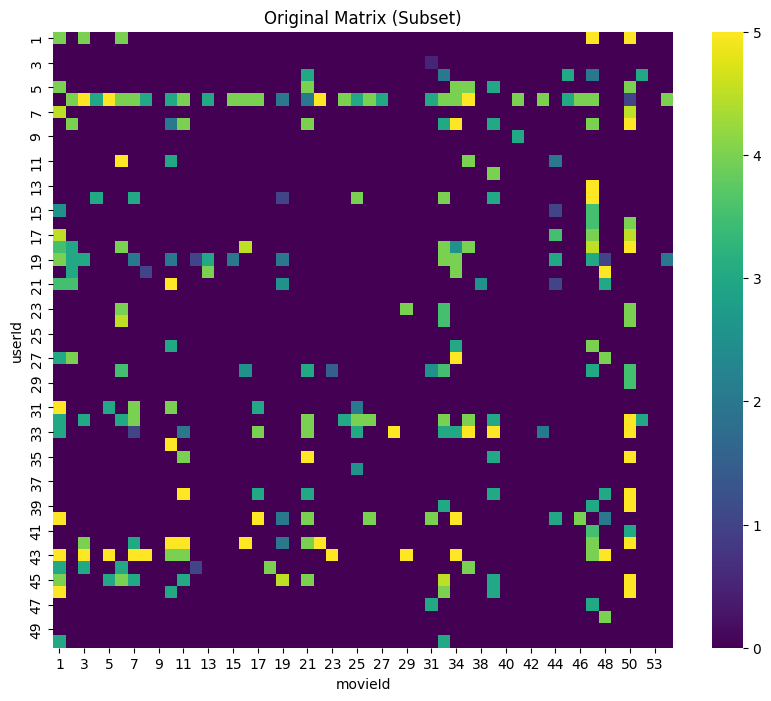

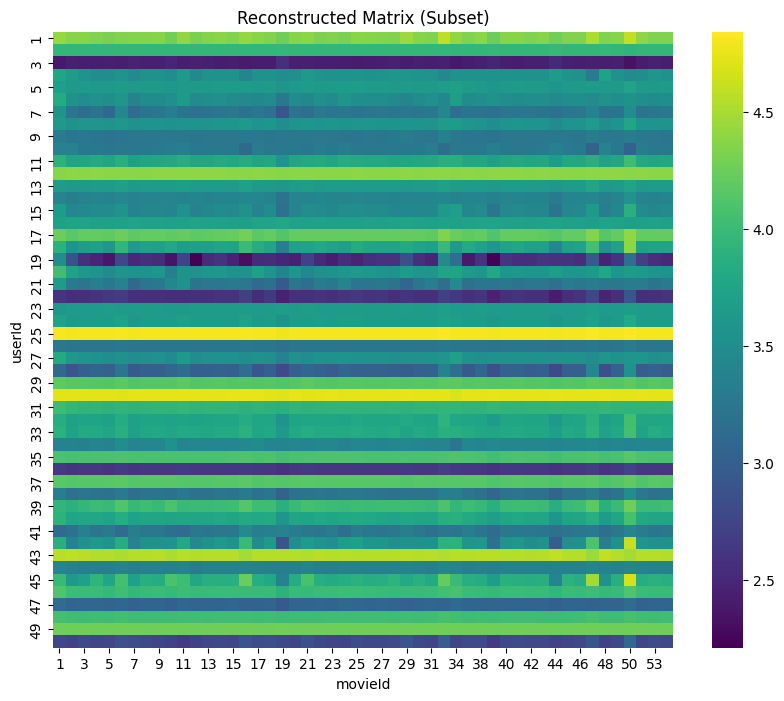

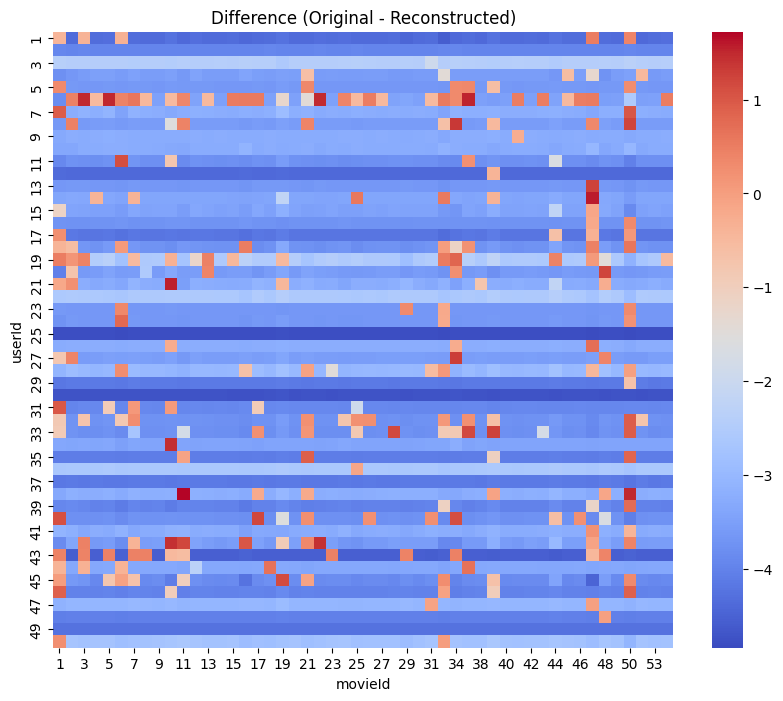

In [9]:
# 9. VISUALIZATION
subset_original = user_item_matrix.fillna(0).iloc[:50, :50]
subset_reconstructed = pred_svd.iloc[:50, :50]

plt.figure(figsize=(10, 8))
sns.heatmap(subset_original, cmap='viridis')
plt.title("Original Matrix (Subset)")
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(subset_reconstructed, cmap='viridis')
plt.title("Reconstructed Matrix (Subset)")
plt.show()

difference = subset_original - subset_reconstructed

plt.figure(figsize=(10, 8))
sns.heatmap(difference, cmap='coolwarm')
plt.title("Difference (Original - Reconstructed)")
plt.show()

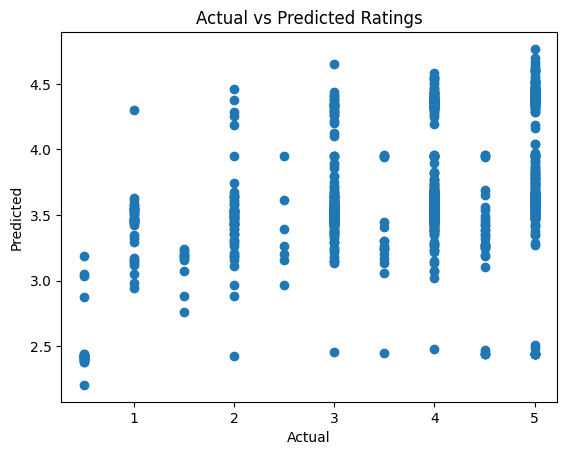

In [10]:
# 10. ACTUAL vs PREDICTED
plt.figure()
plt.scatter(actual[:1000], predicted[:1000])
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Ratings")
plt.show()

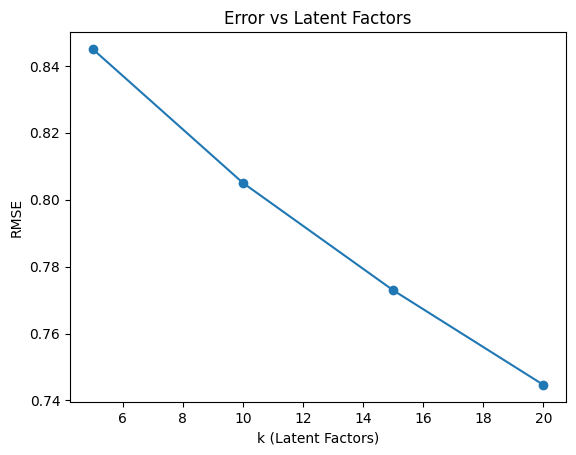

In [11]:
# 11. ERROR vs k
k_values = [5, 10, 15, 20]
errors = []

for k in k_values:
    U_k = U[:, :k]
    sigma_k = np.diag(sigma[:k])
    Vt_k = Vt[:k, :]

    recon = np.dot(np.dot(U_k, sigma_k), Vt_k)
    recon += user_mean.values.reshape(-1, 1)

    pred = recon[mask]
    err = np.sqrt(mean_squared_error(actual, pred))
    errors.append(err)

plt.figure()
plt.plot(k_values, errors, marker='o')
plt.xlabel("k (Latent Factors)")
plt.ylabel("RMSE")
plt.title("Error vs Latent Factors")
plt.show()

# ML Experiment 7 - Scenario 2: GMM Clustering

In [12]:
# 1. IMPORT LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error

In [13]:
# 2. LOAD DATASET
ratings = pd.read_csv('ratings.csv', engine='python', on_bad_lines='skip')
movies = pd.read_csv('movies.csv', engine='python', on_bad_lines='skip')

if 'timestamp' in ratings.columns:
    ratings = ratings.drop('timestamp', axis=1)

ratings = ratings.dropna()

In [14]:
# 3. USER-ITEM MATRIX
user_item_matrix = ratings.pivot(index='userId', columns='movieId', values='rating')

In [15]:
# 4. NORMALIZATION (IMPORTANT FIX)
# Mean centering (similar to SVD improvement)
user_mean = user_item_matrix.mean(axis=1)
matrix_norm = user_item_matrix.sub(user_mean, axis=0)

# Fill missing values AFTER normalization
matrix_filled = matrix_norm.fillna(0)

In [16]:
# 5. APPLY NMF
k = 15
model = NMF(n_components=k, init='random', random_state=42, max_iter=300)

W = model.fit_transform(np.maximum(matrix_filled, 0))  # ensure non-negative
H = model.components_

In [17]:
# 6. RECONSTRUCTION
reconstructed = np.dot(W, H)

# Add mean back
reconstructed += user_mean.values.reshape(-1, 1)

pred_nmf = pd.DataFrame(reconstructed,
                        index=user_item_matrix.index,
                        columns=user_item_matrix.columns)

In [18]:
# 7. EVALUATION
mask = user_item_matrix.notna()

actual = user_item_matrix.values[mask]
predicted = pred_nmf.values[mask]

rmse = np.sqrt(mean_squared_error(actual, predicted))
print("24BAD033 HARSHAVARTHAN SB")
print("NMF RMSE:", rmse)

24BAD033 HARSHAVARTHAN SB
NMF RMSE: 0.8681784424832709


In [19]:
# 8. PRECISION & RECALL
def precision_at_k(user_id, k=5):
    recommended = pred_nmf.loc[user_id].sort_values(ascending=False).head(k).index
    relevant = user_item_matrix.loc[user_id][user_item_matrix.loc[user_id] >= 4].index
    return len(set(recommended) & set(relevant)) / k

def recall_at_k(user_id, k=5):
    recommended = pred_nmf.loc[user_id].sort_values(ascending=False).head(k).index
    relevant = user_item_matrix.loc[user_id][user_item_matrix.loc[user_id] >= 4].index
    return len(set(recommended) & set(relevant)) / len(relevant) if len(relevant) > 0 else 0

print("Precision@5 (User 1):", precision_at_k(1))
print("Recall@5 (User 1):", recall_at_k(1))

Precision@5 (User 1): 1.0
Recall@5 (User 1): 0.025


In [20]:
# 9. RECOMMENDATIONS
def recommend_nmf(user_id, n=5):
    user_row = pred_nmf.loc[user_id]
    already_rated = user_item_matrix.loc[user_id].dropna().index
    recs = user_row.drop(already_rated).sort_values(ascending=False).head(n)
    return movies[movies['movieId'].isin(recs.index)][['movieId', 'title']]

print("\nTop Recommendations for User 1:")
print(recommend_nmf(1))


Top Recommendations for User 1:
      movieId                              title
474       541                Blade Runner (1982)
507       589  Terminator 2: Judgment Day (1991)
659       858              Godfather, The (1972)
902      1200                      Aliens (1986)
1067     1387                        Jaws (1975)


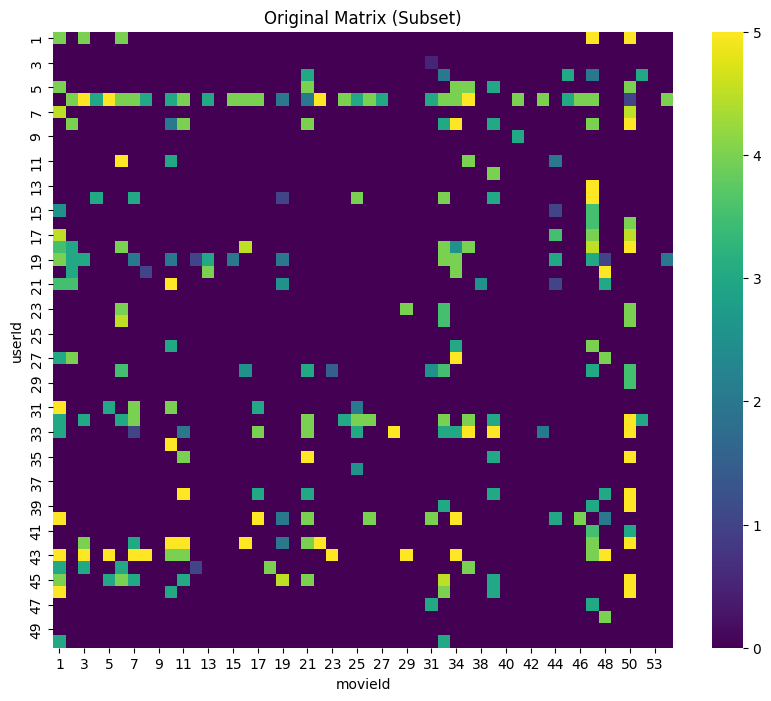

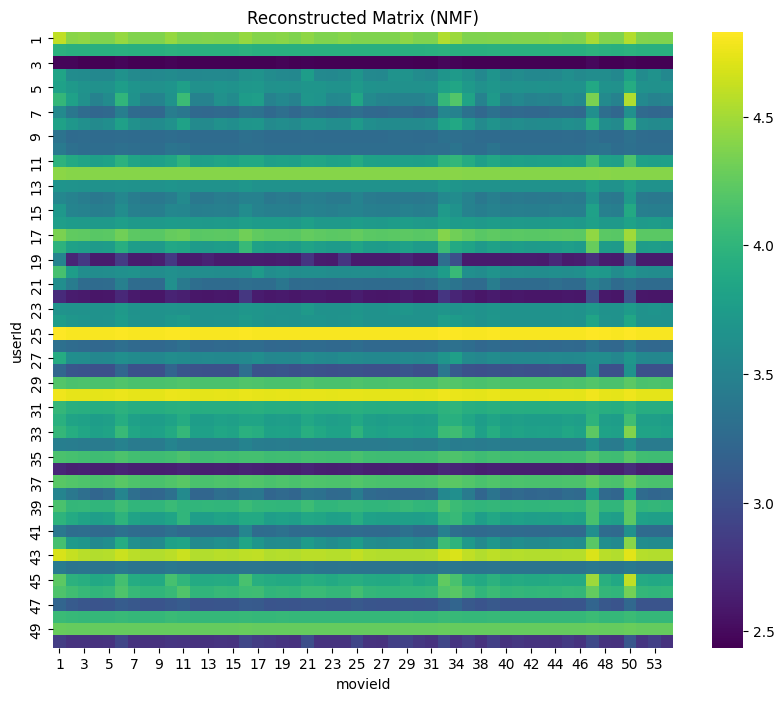

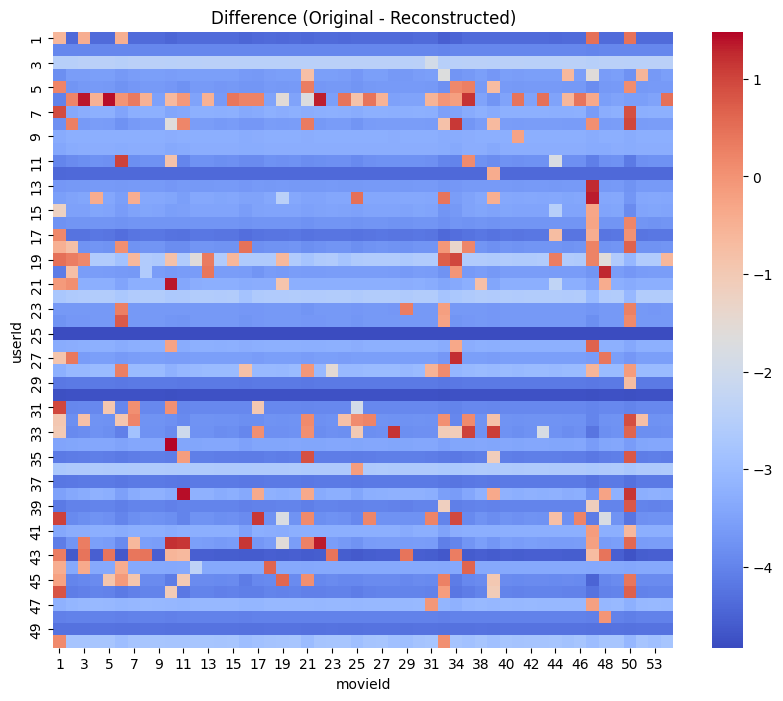

In [21]:
# 10. VISUALIZATION
subset_original = user_item_matrix.fillna(0).iloc[:50, :50]
subset_reconstructed = pred_nmf.iloc[:50, :50]

plt.figure(figsize=(10, 8))
sns.heatmap(subset_original, cmap='viridis')
plt.title("Original Matrix (Subset)")
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(subset_reconstructed, cmap='viridis')
plt.title("Reconstructed Matrix (NMF)")
plt.show()

difference = subset_original - subset_reconstructed

plt.figure(figsize=(10, 8))
sns.heatmap(difference, cmap='coolwarm')
plt.title("Difference (Original - Reconstructed)")
plt.show()

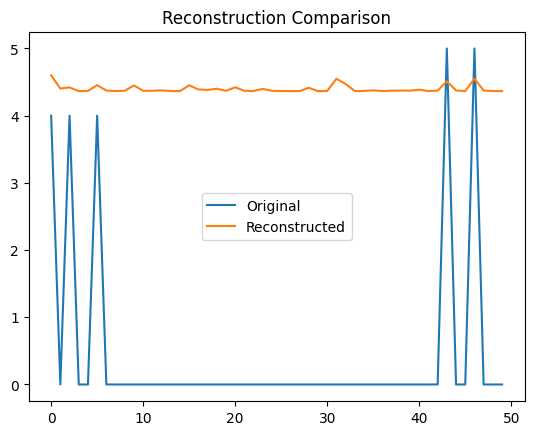

In [22]:
# 11. RECONSTRUCTION COMPARISON
plt.figure()
plt.plot(user_item_matrix.iloc[0].fillna(0).values[:50], label='Original')
plt.plot(pred_nmf.iloc[0].values[:50], label='Reconstructed')
plt.legend()
plt.title("Reconstruction Comparison")
plt.show()

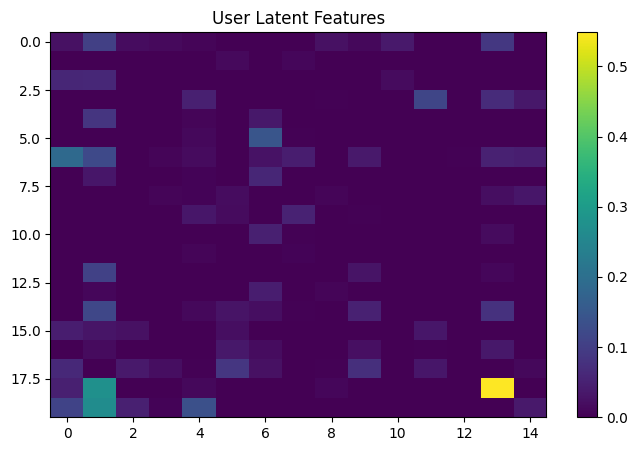

In [23]:
# 12. LATENT FEATURE VISUALIZATION
plt.figure(figsize=(8, 5))
plt.imshow(W[:20, :], aspect='auto')
plt.colorbar()
plt.title("User Latent Features")
plt.show()

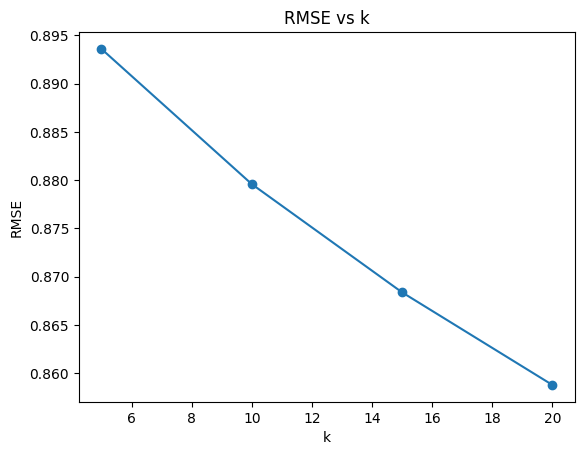

In [24]:
# 13. ERROR vs k
k_values = [5, 10, 15, 20]
rmse_values = []

for k in k_values:
    model = NMF(n_components=k, random_state=42, max_iter=300)
    W_temp = model.fit_transform(np.maximum(matrix_filled, 0))
    H_temp = model.components_
    pred_temp = np.dot(W_temp, H_temp)
    pred_temp += user_mean.values.reshape(-1, 1)

    pred_df = pd.DataFrame(pred_temp,
                           index=user_item_matrix.index,
                           columns=user_item_matrix.columns)

    pred_vals = pred_df.values[mask]
    rmse_k = np.sqrt(mean_squared_error(actual, pred_vals))
    rmse_values.append(rmse_k)

plt.figure()
plt.plot(k_values, rmse_values, marker='o')
plt.title("RMSE vs k")
plt.xlabel("k")
plt.ylabel("RMSE")
plt.show()